# Week 11: Continuous-Time Diffusion — VP-SDE and Probability Flow ODE

In Weeks 9 and 10 we worked with **discrete** timesteps $t \in \{0, 1, \ldots, T-1\}$.  
This week we ask: *what happens as $T \to \infty$?*

We will:
1. Reformulate discrete DDPM as a **continuous-time VP-SDE** with $t \in [0, 1]$
2. Show that the same score model can be sampled with **any number of ODE steps** at inference time
3. Scale to MNIST images (digits 0 and 1) using the same VP-SDE framework

**Datasets used:**
- Cat 2D point cloud (from `cat.png`, same as Week 5)
- MNIST digits 0 and 1

`# TODO` marks exercises for you to complete.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import PIL.Image
from scipy.ndimage import gaussian_filter
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import torchvision

torch.manual_seed(42)
np.random.seed(42)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


---
## Part 1: From Discrete DDPM to the Continuous-Time VP-SDE

In Week 9, the discrete noise schedule gave us $\bar\alpha_n = \prod_{k=1}^n (1 - \beta_k)$ and the forward process
$$q(x_n \mid x_0) = \mathcal{N}(x_n;\, \sqrt{\bar\alpha_n}\, x_0,\; (1 - \bar\alpha_n) I).$$

As $T \to \infty$ with step size $\Delta t = 1/T$, the discrete schedule converges to the **Variance-Preserving SDE (VP-SDE)**:
$$dx = -\tfrac{1}{2}\beta(t)\, x\, dt + \sqrt{\beta(t)}\, dW, \quad t \in [0,1]$$

with a linear schedule $\beta(t) = \beta_{\min} + (\beta_{\max} - \beta_{\min})\, t$.

The marginal at time $t$ is:
$$q(x_t \mid x_0) = \mathcal{N}(x_t;\; \alpha(t)\, x_0,\; \sigma(t)^2 I)$$

where
$$\alpha(t) = \exp\!\left(-\tfrac{1}{2}\int_0^t \beta(s)\,ds\right), \qquad \sigma(t) = \sqrt{1 - \alpha(t)^2}.$$

**Key insight:** training is unchanged — we still minimise
$$\mathcal{L} = \mathbb{E}_{t \sim \mathcal{U}[0,1],\, x_0,\, \varepsilon}\bigl[\|\varepsilon_\theta(x_t, t) - \varepsilon\|^2\bigr]$$
but now $t$ is a **real number** and we can use *any* ODE solver with *any* number of steps at sampling time.

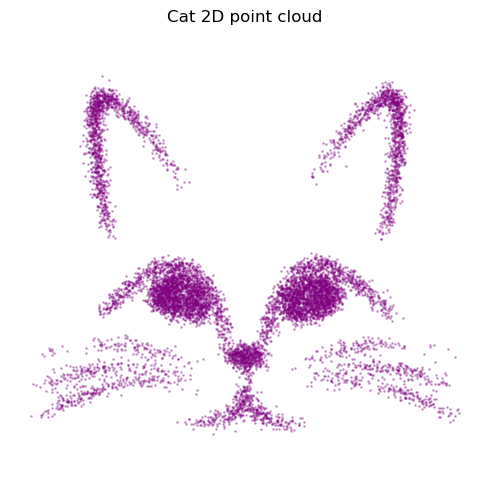

In [2]:
# ── Cat 2D point cloud ──────────────────────────────────────────────────────
def get_cat_samples(n_samples=10000, sigma=2.0):
    """Sample 2D points from a blurred cat image via rejection sampling."""
    try:
        cat = PIL.Image.open('cat.png').convert('L')
        arr = 1.0 - (np.array(cat) / 255.0)  # invert: cat outline is high density
        smoothed = gaussian_filter(arr, sigma=sigma)
        prob_map = smoothed / smoothed.sum()
    except FileNotFoundError:
        print('cat.png not found — using Gaussian fallback')
        return torch.randn(n_samples, 2) * 0.5

    flat = prob_map.flatten()
    idx  = np.random.choice(len(flat), size=n_samples, p=flat)
    rows, cols = np.unravel_index(idx, prob_map.shape)

    pts = np.zeros((n_samples, 2))
    pts[:, 0] = (cols / prob_map.shape[1]) * 2 - 1
    pts[:, 1] = 1 - (rows / prob_map.shape[0]) * 2
    pts += np.random.normal(0, 0.01, pts.shape)
    return torch.tensor(pts, dtype=torch.float32)

cat_data = get_cat_samples(10000, sigma=3.0)

plt.figure(figsize=(5, 5))
plt.scatter(cat_data[:, 0], cat_data[:, 1], s=1, alpha=0.3, color='purple')
plt.title('Cat 2D point cloud')
plt.axis('equal'); plt.axis('off')
plt.tight_layout(); plt.show()

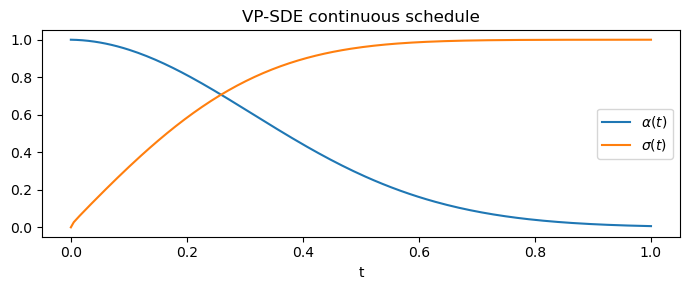

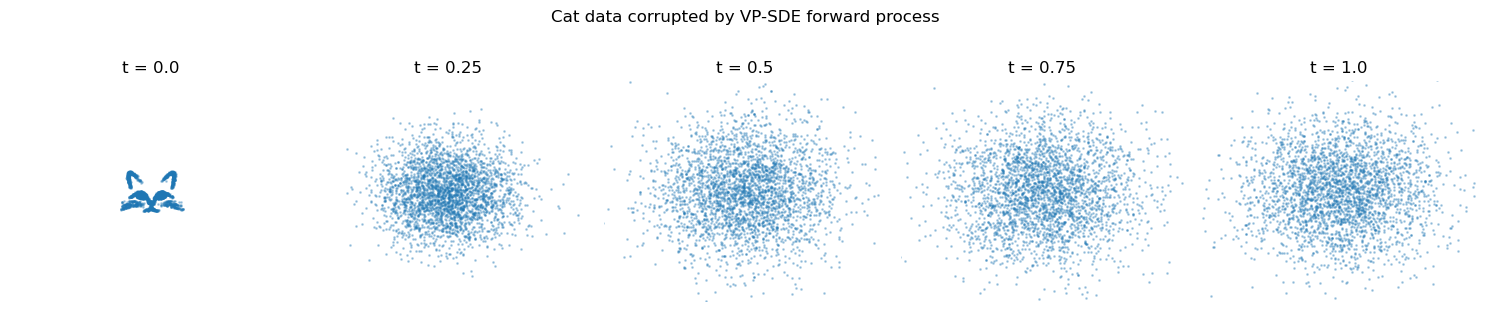

In [3]:
# ── Continuous VP-SDE schedule ───────────────────────────────────────────────
beta_min = 0.1
beta_max = 20.0

def alpha(t: torch.Tensor) -> torch.Tensor:
    """Signal coefficient: alpha(0)=1 (clean data), alpha(1)≈0 (pure noise)."""
    return torch.exp(-0.5 * (beta_min * t + 0.5 * (beta_max - beta_min) * t**2))

def sigma(t: torch.Tensor) -> torch.Tensor:
    """Noise coefficient: sigma(0)=0, sigma(1)≈1."""
    return torch.sqrt(torch.clamp(1.0 - alpha(t)**2, min=1e-8))

def q_sample(x_0: torch.Tensor, t: torch.Tensor, noise=None):
    """Forward process: x_t = alpha(t)*x_0 + sigma(t)*eps."""
    if noise is None:
        noise = torch.randn_like(x_0)
    shape = (-1,) + (1,) * (x_0.dim() - 1)  # broadcast over spatial dims
    a = alpha(t).view(*shape)
    s = sigma(t).view(*shape)
    return a * x_0 + s * noise, noise

# ── Visualise alpha(t) and sigma(t) ─────────────────────────────────────────
t_vals = torch.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t_vals, alpha(t_vals).numpy(), label=r'$\alpha(t)$')
ax.plot(t_vals, sigma(t_vals).numpy(), label=r'$\sigma(t)$')
ax.set_xlabel('t'); ax.legend(); ax.set_title('VP-SDE continuous schedule')
plt.tight_layout(); plt.show()

# ── Show cat data corrupted at different t ───────────────────────────────────
t_show = [0.0, 0.25, 0.5, 0.75, 1.0]
n_show = 3000
x0_show = cat_data[:n_show].to(device)

fig, axes = plt.subplots(1, len(t_show), figsize=(15, 3))
for ax, tv in zip(axes, t_show):
    t_batch = torch.full((n_show,), tv, device=device)
    xt, _ = q_sample(x0_show, t_batch)
    xt = xt.cpu().numpy()
    ax.scatter(xt[:, 0], xt[:, 1], s=1, alpha=0.3)
    ax.set_title(f't = {tv}')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.axis('off')
plt.suptitle('Cat data corrupted by VP-SDE forward process', y=1.02)
plt.tight_layout(); plt.show()

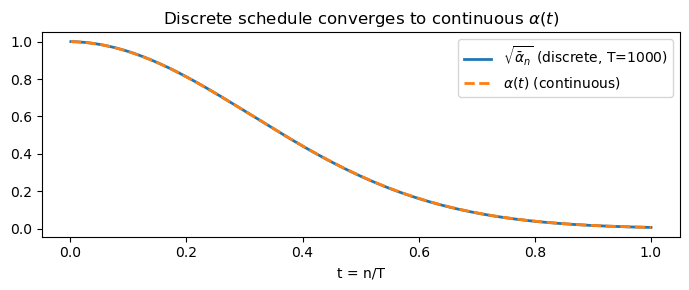

In [4]:
# ── Verify: discrete alpha_cumprod ≈ continuous alpha(t) ────────────────────
T = 1000
betas_disc = torch.linspace(beta_min / T, beta_max / T, T)
alphas_cumprod_disc = torch.cumprod(1.0 - betas_disc, dim=0).sqrt()

t_grid = torch.linspace(1/T, 1.0, T)
alphas_cont = alpha(t_grid)

plt.figure(figsize=(7, 3))
plt.plot(t_grid.numpy(), alphas_cumprod_disc.numpy(), label=r'$\sqrt{\bar\alpha_n}$ (discrete, T=1000)', lw=2)
plt.plot(t_grid.numpy(), alphas_cont.numpy(), '--', label=r'$\alpha(t)$ (continuous)', lw=2)
plt.xlabel('t = n/T'); plt.legend()
plt.title('Discrete schedule converges to continuous $\\alpha(t)$')
plt.tight_layout(); plt.show()

---
## Part 2: Continuous-Time Score Model and ODE Sampling

### The Probability Flow ODE

The VP-SDE has a deterministic counterpart: the **probability flow ODE**
$$\frac{dx}{dt} = -\tfrac{1}{2}\beta(t)\bigl[x + \nabla_x \log p_t(x)\bigr]$$
whose marginals match the SDE at every $t$. We can generate samples by integrating this ODE from $t=1$ (noise) to $t=0$ (data) with **no stochasticity**.

Given $\varepsilon$-prediction, the score is $\nabla_x \log p_t(x_t) \approx -\varepsilon_\theta(x_t, t) / \sigma(t)$.  
Substituting and simplifying yields the **DDIM-style update** for step $\Delta t$:
$$x_{t - \Delta t} = \frac{\alpha(t-\Delta t)}{\alpha(t)}\, x_t \;+\; \left(\sigma(t-\Delta t) - \frac{\alpha(t-\Delta t)}{\alpha(t)}\, \sigma(t)\right)\varepsilon_\theta(x_t, t)$$

This is the **same model as Week 9/10**, but now we can choose any $N$ at sampling time.

In [5]:
class ContinuousMLP(nn.Module):
    """
    MLP for continuous-time epsilon-prediction.
    t ∈ [0,1] is embedded via [sin(pi*t), cos(pi*t)] -> hidden_dim.
    """
    def __init__(self, hidden_dim=256):
        super().__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.GELU(),
        )
        self.net = nn.Sequential(
            nn.Linear(2 + hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),      nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),      nn.GELU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # t: (B,) float in [0, 1]
        t_emb = self.time_embed(
            torch.stack([torch.sin(t * math.pi), torch.cos(t * math.pi)], dim=-1)
        )
        return self.net(torch.cat([x, t_emb], dim=-1))

Epoch  50 | loss 0.1113
Epoch 100 | loss 0.1155
Epoch 150 | loss 0.1129
Epoch 200 | loss 0.1115
Epoch 250 | loss 0.1023
Epoch 300 | loss 0.0995


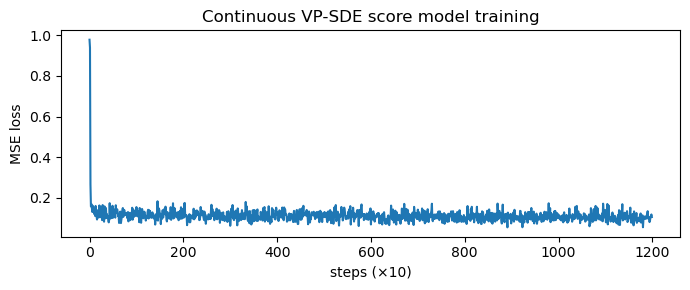

In [6]:
# ── Training: continuous-time epsilon prediction ─────────────────────────────
cat_data = get_cat_samples(10000, sigma=3.0)
dataloader = DataLoader(TensorDataset(cat_data), batch_size=256, shuffle=True)

score_model = ContinuousMLP().to(device)
opt = torch.optim.Adam(score_model.parameters(), lr=1e-3)

losses = []
for epoch in range(300):
    for (x_0,) in dataloader:
        x_0 = x_0.to(device)
        B = x_0.shape[0]

        # Sample t ~ Uniform[0, 1]  (continuous, not discrete integers)
        t = torch.rand(B, device=device)

        # Corrupt data
        x_t, noise = q_sample(x_0, t)

        eps_pred = score_model(x_t, t)
        loss = F.mse_loss(eps_pred, noise)

        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:3d} | loss {np.mean(losses[-len(dataloader):]):.4f}')

plt.figure(figsize=(7, 3))
plt.plot(losses[::10]); plt.xlabel('steps (×10)'); plt.ylabel('MSE loss')
plt.title('Continuous VP-SDE score model training')
plt.tight_layout(); plt.show()

In [7]:
@torch.no_grad()
def sample_ode(model, n_samples=2000, N=100):
    """
    Euler solver for the probability flow ODE.
    Integrates from t=1 (noise) to t≈0 (data) in N steps.

    DDIM-style update:
        x_{t-dt} = (alpha(t-dt)/alpha(t)) * x_t
                 + (sigma(t-dt) - (alpha(t-dt)/alpha(t)) * sigma(t)) * eps_pred
    """
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    ts = torch.linspace(1.0, 1e-3, N + 1, device=device)

    for i in range(N):
        t_curr = ts[i]
        t_next = ts[i + 1]

        eps_pred = model(x, t_curr.expand(n_samples))

        a_c = alpha(t_curr)
        a_n = alpha(t_next)
        s_c = sigma(t_curr)
        s_n = sigma(t_next)

        # DDIM update step
        x = (a_n / a_c) * x + (s_n - (a_n / a_c) * s_c) * eps_pred

    return x.cpu().numpy()

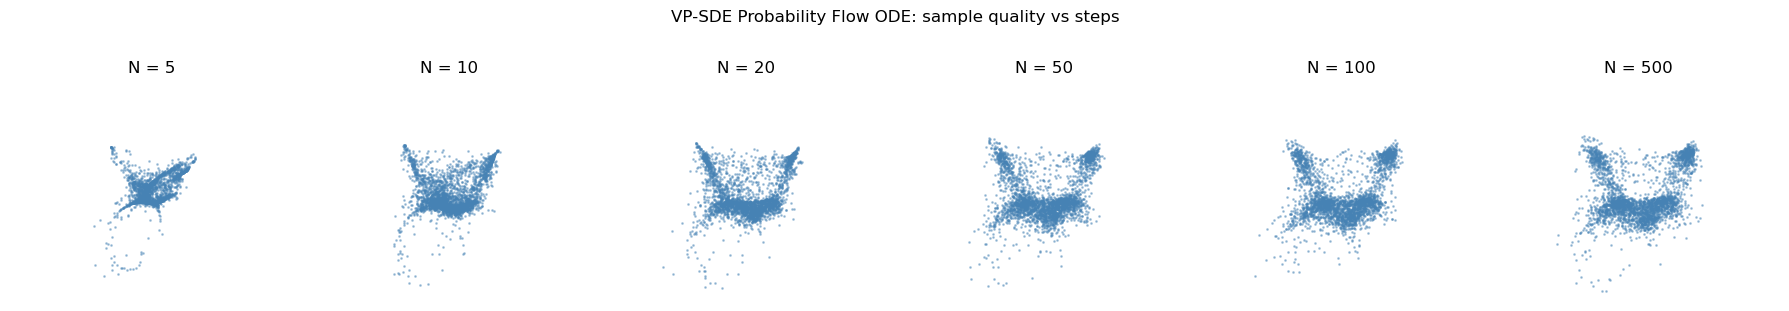

In [8]:
# ── Explore: sample quality vs number of ODE steps ──────────────────────────
step_counts = [5, 10, 20, 50, 100, 500]
fig, axes = plt.subplots(1, len(step_counts), figsize=(18, 3))

for ax, N in zip(axes, step_counts):
    samples = sample_ode(score_model, n_samples=3000, N=N)
    ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.4, color='steelblue')
    ax.set_title(f'N = {N}')
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.axis('off')

plt.suptitle('VP-SDE Probability Flow ODE: sample quality vs steps', y=1.02)
plt.tight_layout(); plt.show()

## 2b. Stochastic Sampling via the Reverse VP-SDE

The probability flow ODE is **deterministic** — given the same initial noise, it always produces
the same output. But the original VP-SDE also admits a **stochastic** reverse process
(Anderson, 1982):

$$dx = \underbrace{\left[-\tfrac{1}{2}\beta(t)\,x - \beta(t)\,\nabla_x \log p_t(x)\right]}_{\text{drift}}\,dt + \underbrace{\sqrt{\beta(t)}}_{\text{diffusion}}\,d\bar{W}$$

Substituting $\nabla_x \log p_t(x) \approx -\varepsilon_\theta(x,t)/\sigma(t)$ and applying
**Euler–Maruyama** with step size $\Delta t = t_{\text{curr}} - t_{\text{next}} > 0$:

$$x_{t-\Delta t} = x_t
  + \left[-\tfrac{1}{2}\beta(t)\,x_t + \frac{\beta(t)}{\sigma(t)}\,\varepsilon_\theta(x_t,t)\right]\Delta t
  + \sqrt{\beta(t)\,\Delta t}\; z, \quad z\sim\mathcal{N}(0,I)$$

| | **PFODE** | **Reverse VP-SDE (EM)** |
|---|---|---|
| Stochastic? | No | Yes — new $z$ each step |
| Same noise → same output? | ✓ | ✗ |
| Noise injected per step | None | $\sqrt{\beta(t)\Delta t}\,z$ |
| Typical quality at low $N$ | Decent | Noisier (EM error) |
| Diversity | Limited by initial noise | Higher |

In [18]:
@torch.no_grad()
def sample_sde(model, n_samples=2000, N=100):
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    ts = torch.linspace(1.0, 1e-3, N + 1, device=device)

    for i in range(N):
        t_curr = ts[i]
        t_next = ts[i + 1]
        dt     = t_curr - t_next

        eps_pred = model(x, t_curr.expand(n_samples))
        beta_t   = beta_min + (beta_max - beta_min) * t_curr
        s_c      = sigma(t_curr)
        
        # Do not inject noise on the final step
        z = torch.randn_like(x) if i < N - 1 else 0

        drift     = (-0.5 * beta_t * x + (beta_t / s_c) * eps_pred) * dt
        diffusion = torch.sqrt(beta_t * dt) * z
        
        # Subtract the drift because we are moving backward in time
        x = x - drift + diffusion

    return x.cpu().numpy()

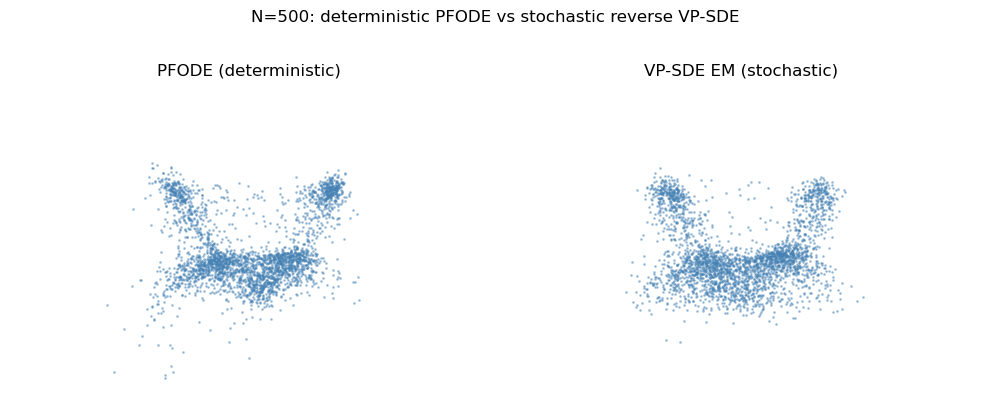

In [21]:
# ── PFODE vs SDE: side-by-side at N=500 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, samples) in zip(axes, [
        ('PFODE (deterministic)', sample_ode(score_model, n_samples=3000, N=500)),
        ('VP-SDE EM (stochastic)', sample_sde(score_model, n_samples=3000, N=500)),
]):
    ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.4, color='steelblue')
    ax.set_title(label)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.axis('off')
plt.suptitle('N=500: deterministic PFODE vs stochastic reverse VP-SDE', y=1.02)
plt.tight_layout(); plt.show()

### Discussion

1. At what value of $N$ does the cat shape first become recognisable? At what $N$ does it look sharp?
2. The ODE sampler is **deterministic** — for a fixed initial noise, it always produces the same output. What does this imply about diversity compared to stochastic DDPM?
3. Why might VP-SDE probability flow ODE paths require more steps than you might expect? Think about the geometry of the trajectories.
4. Run `sample_sde` and `sample_ode` from the **same** initial noise tensor. Are the outputs identical? Run them again with different seeds — how does diversity compare? At $N=5$, which sampler produces cleaner samples?

MNIST 0&1 training samples: 12665


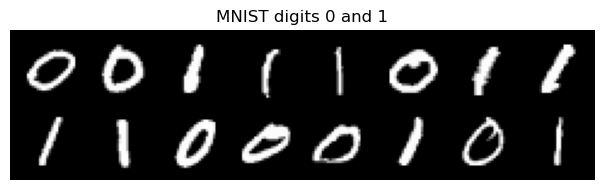

In [11]:
# ── MNIST digits 0 and 1 ─────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),   # map to [-1, 1]
])
mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)

# Filter to digits 0 and 1
idx = (mnist_train.targets == 0) | (mnist_train.targets == 1)
mnist_train.targets = mnist_train.targets[idx]
mnist_train.data    = mnist_train.data[idx]

img_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
print(f'MNIST 0&1 training samples: {len(mnist_train)}')

# Quick preview
x_preview, _ = next(iter(img_loader))
grid = torchvision.utils.make_grid(x_preview[:16], nrow=8, normalize=True)
plt.figure(figsize=(10, 2))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
plt.axis('off'); plt.title('MNIST digits 0 and 1')
plt.tight_layout(); plt.show()

---
## Part 3: VP-SDE and PFODE on MNIST (Digits 0 and 1)

We now apply the **same** VP-SDE framework from Parts 1 and 2 to **28×28 grayscale images**, using a small U-Net as the noise-prediction network.

The training objective is identical to Part 2 — minimise $\|\varepsilon_\theta(x_t, t) - \varepsilon\|^2$ with continuous $t \sim \mathcal{U}[0,1]$.  
The PFODE sampler uses the exact same DDIM-style update as before.

In [12]:
from unet_flow import MiniUNetContinuous

unet = MiniUNetContinuous(in_channels=1, time_emb_dim=64).to(device)
print(f'MiniUNetContinuous parameters: {sum(p.numel() for p in unet.parameters()):,}')

MiniUNetContinuous parameters: 145,601


In [13]:
# ── VP-SDE training on MNIST images ─────────────────────────────────────────
opt_unet   = torch.optim.Adam(unet.parameters(), lr=3e-4)
sched_unet = torch.optim.lr_scheduler.CosineAnnealingLR(opt_unet, T_max=20)
epochs_img = 20
losses_img = []

for epoch in range(epochs_img):
    for x_0, _ in img_loader:
        x_0 = x_0.to(device)
        B = x_0.shape[0]

        # Sample t ~ Uniform[0, 1]
        t = torch.rand(B, device=device)

        # Corrupt x_0 — q_sample broadcasts over spatial dims automatically
        x_t, noise = q_sample(x_0, t)

        eps_pred = unet(x_t, t)
        loss = F.mse_loss(eps_pred, noise)

        opt_unet.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        opt_unet.step()
        losses_img.append(loss.item())

    sched_unet.step()
    print(f'Epoch {epoch+1:2d}/{epochs_img} | loss {np.mean(losses_img[-len(img_loader):]):.4f}')

Epoch  1/20 | loss 0.2975
Epoch  2/20 | loss 0.0797
Epoch  3/20 | loss 0.0591
Epoch  4/20 | loss 0.0524
Epoch  5/20 | loss 0.0464
Epoch  6/20 | loss 0.0435
Epoch  7/20 | loss 0.0415
Epoch  8/20 | loss 0.0415
Epoch  9/20 | loss 0.0389
Epoch 10/20 | loss 0.0375
Epoch 11/20 | loss 0.0368
Epoch 12/20 | loss 0.0358
Epoch 13/20 | loss 0.0354
Epoch 14/20 | loss 0.0348
Epoch 15/20 | loss 0.0347
Epoch 16/20 | loss 0.0344
Epoch 17/20 | loss 0.0340
Epoch 18/20 | loss 0.0346
Epoch 19/20 | loss 0.0334
Epoch 20/20 | loss 0.0341


In [14]:
@torch.no_grad()
def sample_pfode_mnist(model, n_samples=8, N=100):
    """
    PFODE sampler for images — same DDIM update as sample_ode() in Part 2.
    Integrates from t=1 (noise) to t≈0 (data) in N steps.
    """
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)
    ts = torch.linspace(1.0, 1e-3, N + 1, device=device)

    for i in range(N):
        t_curr = ts[i]
        t_next = ts[i + 1]

        eps_pred = model(x, t_curr.expand(n_samples))

        a_c = alpha(t_curr)
        a_n = alpha(t_next)
        s_c = sigma(t_curr)
        s_n = sigma(t_next)

        # DDIM update — identical to Part 2
        x = (a_n / a_c) * x + (s_n - (a_n / a_c) * s_c) * eps_pred

    return x.cpu()

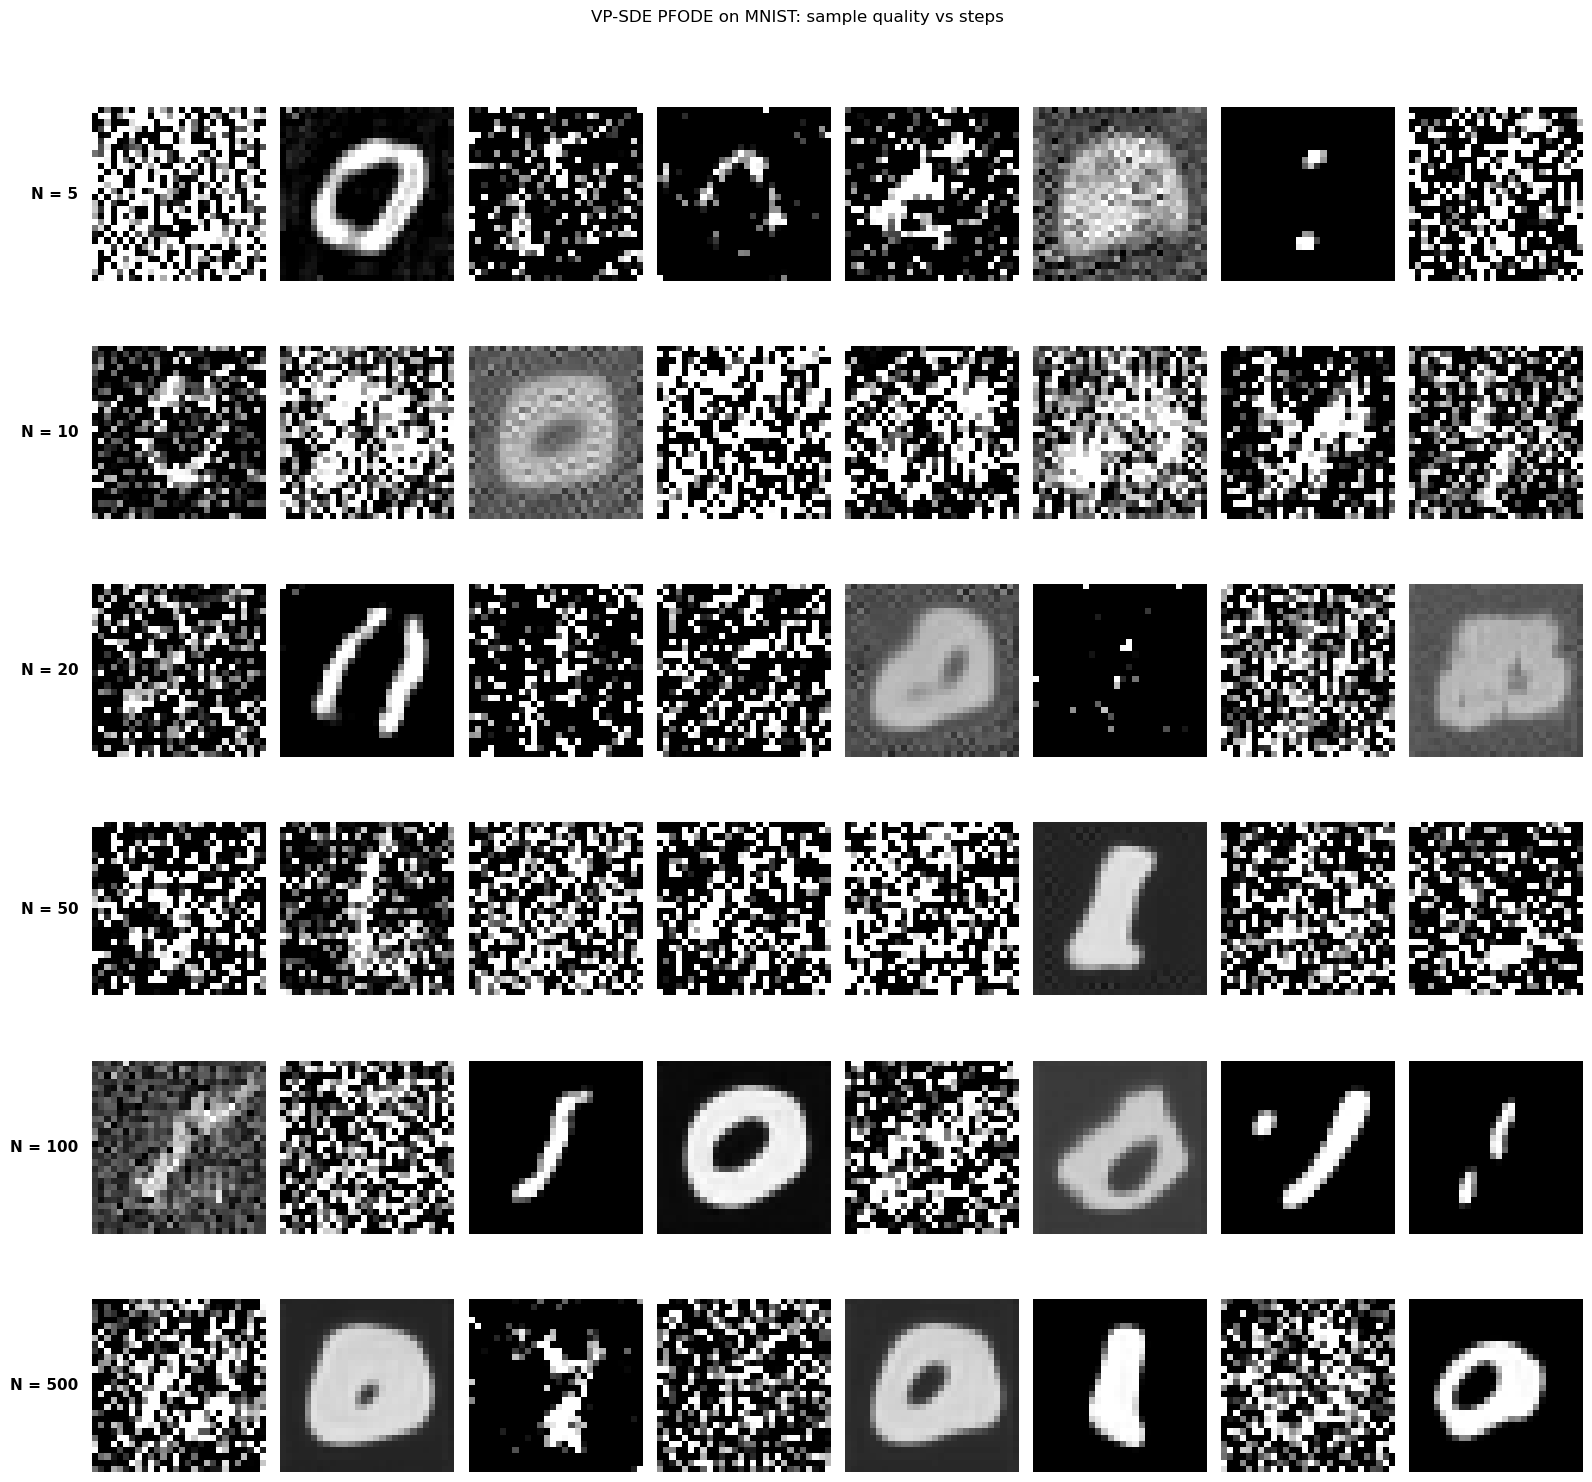

In [15]:
# ── Explore: image quality vs number of PFODE steps ─────────────────────────
step_counts = [5, 10, 20, 50, 100, 500]
n_per_row   = 8

fig, axes = plt.subplots(len(step_counts), n_per_row,
                         figsize=(16, 2.5 * len(step_counts)))

for row, N in enumerate(step_counts):
    imgs = sample_pfode_mnist(unet, n_samples=n_per_row, N=N)
    for col in range(n_per_row):
        img = np.clip((imgs[col].squeeze().numpy() + 1) / 2, 0, 1)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    # Row label placed to the LEFT using transAxes coords — survives axis('off')
    axes[row, 0].text(-0.08, 0.5, f'N = {N}',
                      transform=axes[row, 0].transAxes,
                      fontsize=11, ha='right', va='center', fontweight='bold')

plt.suptitle('VP-SDE PFODE on MNIST: sample quality vs steps', y=1.01)
fig.subplots_adjust(left=0.08)
plt.tight_layout(); plt.show()

## 3b. Stochastic VP-SDE Sampling on MNIST

The same Euler–Maruyama update from Part 2 applies directly to images — the only difference
is the tensor shape (4-D instead of 2-D). Implement `sample_vpsde_mnist` below, then compare
its outputs to `sample_pfode_mnist` at the same step count. There are much more sophisticated 
integrators to use for PF-ODE and VP-SDE that would improve performance, but we stick to the 
basic ones. As the stepsize approaches 0, the integrator used does not matter! SDE typically
requires more steps than PF-ODE but achieves greater generalization.

In [16]:
@torch.no_grad()
def sample_vpsde_mnist(model, n_samples=8, N=100):
    model.eval()
    x  = torch.randn(n_samples, 1, 28, 28, device=device)
    ts = torch.linspace(1.0, 1e-3, N + 1, device=device)

    for i in range(N):
        t_curr = ts[i]
        t_next = ts[i + 1]
        dt     = t_curr - t_next

        eps_pred = model(x, t_curr.expand(n_samples))
        beta_t   = beta_min + (beta_max - beta_min) * t_curr
        s_c      = sigma(t_curr)
        
        # Do not inject noise on the final step
        z = torch.randn_like(x) if i < N - 1 else 0

        drift     = (-0.5 * beta_t * x + (beta_t / s_c) * eps_pred) * dt
        diffusion = torch.sqrt(beta_t * dt) * z
        
        # Subtract the drift here as well
        x = x - drift + diffusion

    return x.cpu()

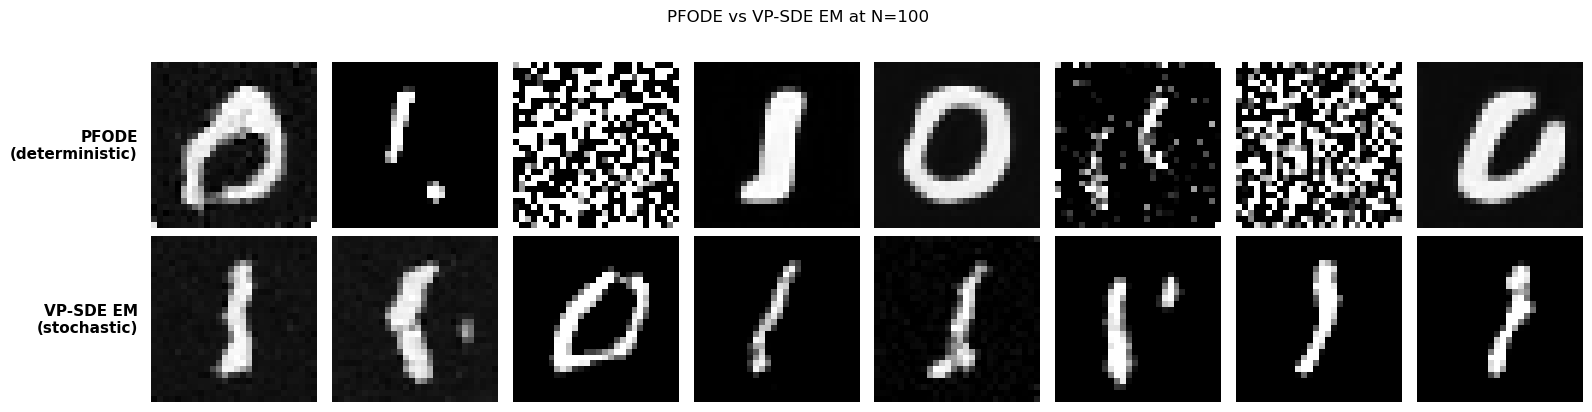

In [17]:
# ── PFODE vs VP-SDE EM: side-by-side image grids at N=100 ───────────────────
N_cmp  = 100
n_show = 8
pfode_imgs = sample_pfode_mnist(unet, n_samples=n_show, N=N_cmp)
sde_imgs   = sample_vpsde_mnist(unet, n_samples=n_show, N=N_cmp)

fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
row_labels = ['PFODE\n(deterministic)', 'VP-SDE EM\n(stochastic)']
for col in range(n_show):
    for row, imgs in enumerate([pfode_imgs, sde_imgs]):
        img = np.clip((imgs[col].squeeze().numpy() + 1) / 2, 0, 1)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
for row, label in enumerate(row_labels):
    axes[row, 0].text(-0.08, 0.5, label,
                      transform=axes[row, 0].transAxes,
                      fontsize=11, ha='right', va='center', fontweight='bold')

plt.suptitle(f'PFODE vs VP-SDE EM at N={N_cmp}', y=1.02)
fig.subplots_adjust(left=0.12)
plt.tight_layout(); plt.show()

### Final Discussion

1. Compare the minimum viable $N$ for the cat 2D experiment (Part 2) vs MNIST (Part 3). Why do images require more steps for recognisable quality?
2. In Part 3 we trained a single unconditional model on digits 0 *and* 1 mixed together. What would you expect to see in the samples — pure 0s, pure 1s, or a mix? Does your observation match the expectation?
3. **Connecting Weeks 9–11:**  
   - Week 9: discrete DDPM, score matching  
   - Week 10: conditioning via classifier guidance and CFG  
   - Week 11: continuous time, VP-SDE, probability flow ODE  
   
   What is the single most important idea connecting all three frameworks?
4. Run `sample_vpsde_mnist` and `sample_pfode_mnist` from the same seed at $N=20$. Which looks sharper? Why does the SDE sampler tend to be noisier at low $N$?
5. At $N=500$ do PFODE and VP-SDE EM outputs look similar? What does this tell you about the relationship between the two samplers?